# 04 - VAE Training on Correlation Matrices

This notebook trains a **Variational Autoencoder (VAE)** on correlation tensors saved in `data/processed/corr_windows_tensor_data_*.pt`.

Key design choices:
- **Base architecture**: VAE (encoder/decoder MLP + reparameterization)
- **Input mode switch** via `NUM_FACTORS`:
  - `NUM_FACTORS = None` -> use only the **upper triangular** part of the original correlation matrix
  - `NUM_FACTORS = k` with `1 <= k < D` -> use top-`k` **eigenvector loadings**

This keeps one training pipeline while enabling optional eigen-filtered inputs.

In [116]:
import random
from pathlib import Path
import sys
import json

import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import matplotlib.pyplot as plt

In [117]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [118]:
MY_FILE_NAME = "corr_windows_tensor_data_00_20_w724_s10.pt"
if 'google.colab' in sys.modules:
    print("Ambiente rilevato: Google Colab")
    IS_COLAB = True
else:
    print("Ambiente rilevato: Locale (PC)")
    IS_COLAB = False


if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    processed_dir = Path("/content/drive/MyDrive/dataset_tesi")
else:
    project_root = Path.cwd().resolve().parent
    processed_dir = project_root / "data" / "processed"

selected_file = processed_dir / MY_FILE_NAME

if not selected_file.exists():
    raise FileNotFoundError(
        f"Errore: Il file '{MY_FILE_NAME}' non e stato trovato in: {processed_dir.absolute()}"
    )

print(f"File selezionato: {selected_file.name}")

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # number or None
MATRIX_END = None  # number or None, Example: 500 to use only the first 500 matrices
print(f"Matrix range: [{MATRIX_START}, {MATRIX_END})")

Ambiente rilevato: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File selezionato: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [119]:
data = torch.load(selected_file, map_location="cpu")

corr_tensor = data["corr_tensor"].float()
window_ranges = data.get("window_ranges", None)
timestamps = data.get("timestamps", None)
window_length = data.get("window_length", None)
stride = data.get("stride", None)
tickers = data.get("tickers", None)

orig_N, D, D2 = corr_tensor.shape
if D != D2:
    raise ValueError(f"Matrices are not square: {corr_tensor.shape}")

start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_N if MATRIX_END is None else int(MATRIX_END)
if not (0 <= start_idx < end_idx <= orig_N):
    raise ValueError(
        f"Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_N}"
    )

corr_tensor = corr_tensor[start_idx:end_idx]
if window_ranges is not None and len(window_ranges) == orig_N:
    window_ranges = window_ranges[start_idx:end_idx]

N, D, D2 = corr_tensor.shape
print(f"corr_tensor shape (selected range): {corr_tensor.shape}")
print(f"using matrices: [{start_idx}, {end_idx}) out of {orig_N}")
print(f"dtype: {corr_tensor.dtype}")
print(f"window_length: {window_length}, stride: {stride}")
print(f"#tickers: {len(tickers) if tickers is not None else 'N/A'}")

corr_tensor shape (selected range): torch.Size([412, 362, 362])
using matrices: [49, 461) out of 461
dtype: torch.float32
window_length: 724, stride: 10
#tickers: 362


In [120]:
# Input representation selector
NUM_FACTORS = 15  # None -> upper triangular. Integer with 1 <= NUM_FACTORS < D -> spectral loadings.

INPUT_MODE = "upper_triangular" if NUM_FACTORS is None else "spectral_loadings"

# Upper triangular indices
tri_u_idx = torch.triu_indices(row=D, col=D, offset=1)
tri_size = tri_u_idx.shape[1]

loadings_ref = None  # Filled only in spectral mode.

if NUM_FACTORS is None:
    # use upper-triangular coefficients as VAE input.
    X = corr_tensor[:, tri_u_idx[0], tri_u_idx[1]].contiguous()
    print(f"Input mode: {INPUT_MODE}")
    print(f"Upper triangular indices shape: {tri_u_idx.shape}")
    print(f"VAE input dimension (upper triangular): {tri_size}")
else:
    if not isinstance(NUM_FACTORS, int):
        raise TypeError("NUM_FACTORS must be None or an integer.")
    if not (1 <= NUM_FACTORS < D):
        raise ValueError(f"NUM_FACTORS must satisfy 1 <= NUM_FACTORS < D (= {D}).")

    # spectral preprocessing: keep top-k eigenspaces and build weighted loadings.
    eigvals_asc, eigvecs_asc = torch.linalg.eigh(corr_tensor)
    eigvals_top = torch.flip(eigvals_asc[:, -NUM_FACTORS:], dims=[1])
    eigvecs_top = torch.flip(eigvecs_asc[:, :, -NUM_FACTORS:], dims=[2])
    eigvals_top = torch.clamp(eigvals_top, min=0.0)

    loadings_ref = eigvecs_top * torch.sqrt(eigvals_top).unsqueeze(1)  # (N, D, K)
    X = loadings_ref.reshape(N, D * NUM_FACTORS).contiguous()

    print(f"Input mode: {INPUT_MODE}")
    print(f"Selected eigen-factors (K): {NUM_FACTORS}")
    print(f"Loadings tensor shape: {loadings_ref.shape} (N, D, K)")
    print(f"VAE input dimension (D*K): {X.shape[1]}")

print(f"X shape: {X.shape}")

Input mode: spectral_loadings
Selected eigen-factors (K): 15
Loadings tensor shape: torch.Size([412, 362, 15]) (N, D, K)
VAE input dimension (D*K): 5430
X shape: torch.Size([412, 5430])


In [121]:
# Main hyperparameters
RUN = "8"
BATCH_SIZE = 4
VAL_RATIO = 0.2
TEST_RATIO = 0.1
LATENT_DIM = 3
HIDDEN_DIMS = [4096, 2048, 1024, 512, 256, 64, 32, 16, 8]
BETA = 1
LEARNING_RATE = 1e-7
WEIGHT_DECAY = 1e-5
EPOCHS = 200
USE_SCHEDULER = False

# Train/validation/test split
if VAL_RATIO + TEST_RATIO >= 1.0:
    raise ValueError("VAL_RATIO + TEST_RATIO must be < 1.0")

full_ds = TensorDataset(X)
n_total = len(full_ds)
test_size = int(n_total * TEST_RATIO)
val_size = int(n_total * VAL_RATIO)
train_size = n_total - val_size - test_size

train_ds, val_ds, test_ds = random_split(
    full_ds,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
 )

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train size: {train_size}")
print(f"Val size:   {val_size}")
print(f"Test size:  {test_size}")
print(f"Input mode: {INPUT_MODE}")
if NUM_FACTORS is not None:
    print(f"NUM_FACTORS: {NUM_FACTORS}")

Train size: 289
Val size:   82
Test size:  41
Input mode: spectral_loadings
NUM_FACTORS: 15


In [122]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.ReLU())
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.ReLU())
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [123]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    # Average KL divergence per batch
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, recon, kl


def run_epoch(model, loader, optimizer=None, beta=1.0, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_samples = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        bs = x_batch.size(0)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train): # Only compute gradients during training, equal to "with torch.no_grad()" when is_train is False
            x_hat, mu, logvar = model(x_batch)
            loss, recon, kl = vae_loss(x_hat, x_batch, mu, logvar, beta=beta)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * bs
        total_recon += recon.item() * bs
        total_kl += kl.item() * bs
        total_samples += bs

    return {
        "loss": total_loss / total_samples,
        "recon": total_recon / total_samples,
        "kl": total_kl / total_samples,
    }

In [124]:
input_dim = X.shape[1]
model = VAE(input_dim=input_dim, hidden_dims=HIDDEN_DIMS, latent_dim=LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

if USE_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=max(1, EPOCHS // 5),
        T_mult=1,
        eta_min=LEARNING_RATE * 1e-2,
    )
else:
    scheduler = None

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
}

best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    tr = run_epoch(model, train_loader, optimizer=optimizer, beta=BETA, device=DEVICE)
    va = run_epoch(model, val_loader, optimizer=None, beta=BETA, device=DEVICE)

    history["train_loss"].append(tr["loss"])
    history["train_recon"].append(tr["recon"])
    history["train_kl"].append(tr["kl"])
    history["val_loss"].append(va["loss"])
    history["val_recon"].append(va["recon"])
    history["val_kl"].append(va["kl"])

    if va["loss"] < best_val:
        best_val = va["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"LR {current_lr:.8f} | "
        f"Train Loss {tr['loss']:.6f} (Recon {tr['recon']:.6f}, KL {tr['kl']:.6f}) | "
        f"Val Loss {va['loss']:.6f} (Recon {va['recon']:.6f}, KL {va['kl']:.6f})"
    )

    if USE_SCHEDULER:
        scheduler.step()

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best weights with val_loss = {best_val:.6f}")

Epoch 001/200 | LR 0.00000010 | Train Loss 0.053875 (Recon 0.037650, KL 0.016225) | Val Loss 0.054459 (Recon 0.038238, KL 0.016221)
Epoch 002/200 | LR 0.00000010 | Train Loss 0.053843 (Recon 0.037626, KL 0.016218) | Val Loss 0.054429 (Recon 0.038215, KL 0.016214)
Epoch 003/200 | LR 0.00000010 | Train Loss 0.053812 (Recon 0.037601, KL 0.016210) | Val Loss 0.054399 (Recon 0.038192, KL 0.016207)
Epoch 004/200 | LR 0.00000010 | Train Loss 0.053780 (Recon 0.037577, KL 0.016203) | Val Loss 0.054369 (Recon 0.038169, KL 0.016200)
Epoch 005/200 | LR 0.00000010 | Train Loss 0.053749 (Recon 0.037553, KL 0.016196) | Val Loss 0.054338 (Recon 0.038146, KL 0.016193)
Epoch 006/200 | LR 0.00000010 | Train Loss 0.053718 (Recon 0.037529, KL 0.016189) | Val Loss 0.054308 (Recon 0.038123, KL 0.016186)
Epoch 007/200 | LR 0.00000010 | Train Loss 0.053687 (Recon 0.037505, KL 0.016182) | Val Loss 0.054278 (Recon 0.038100, KL 0.016179)
Epoch 008/200 | LR 0.00000010 | Train Loss 0.053655 (Recon 0.037481, KL 0.01

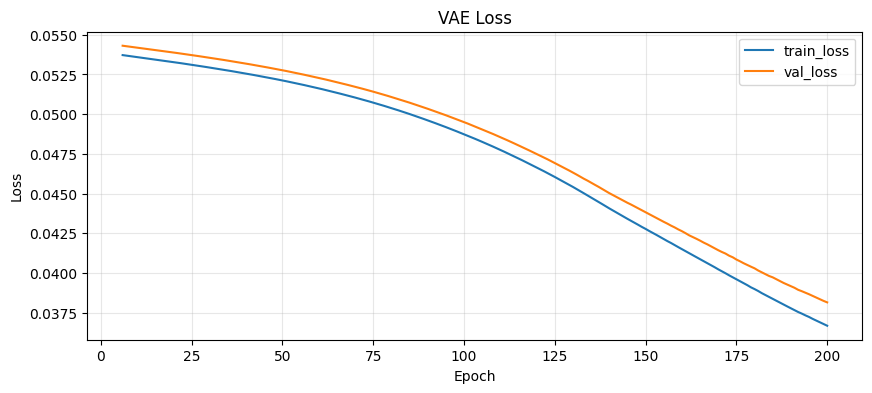

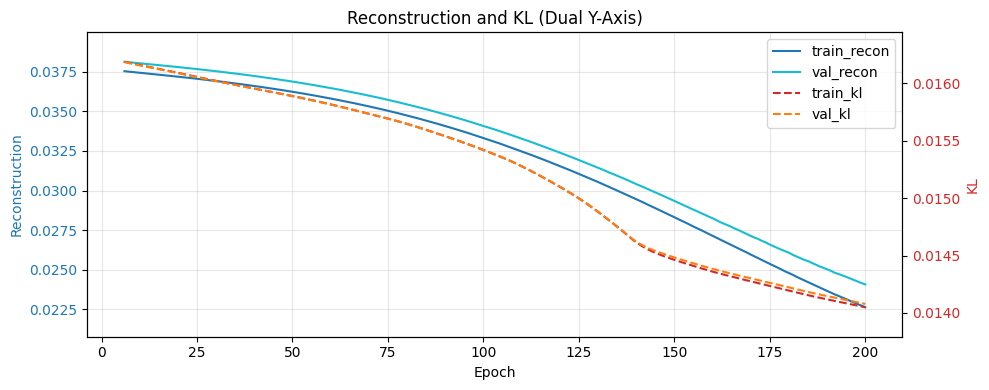

Plots saved in: /content/drive/MyDrive/best_models_tesi/results_w724_s10_eigK15_RUN8


In [125]:
epochs = np.arange(1, EPOCHS + 1)

# Prepare output directory for saving plots
if IS_COLAB:
    base_save_dir = Path("/content/drive/MyDrive/best_models_tesi")
else:
    base_save_dir = project_root / "models"

mode_suffix = "triU" if NUM_FACTORS is None else f"eigK{NUM_FACTORS}"
folder_name = f"results_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}"
run_dir = base_save_dir / folder_name
run_dir.mkdir(parents=True, exist_ok=True)

# First plot: VAE Loss
plt.figure(figsize=(10, 4))
plt.plot(epochs[5:], history["train_loss"][5:], label="train_loss")
plt.plot(epochs[5:], history["val_loss"][5:], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(run_dir / f"vae_loss_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

# Second plot: Reconstruction (left y-axis) and KL (right y-axis)
start_plot = 5
ep_plot = epochs[start_plot:]

train_recon = np.asarray(history["train_recon"][start_plot:])
val_recon = np.asarray(history["val_recon"][start_plot:])
train_kl = np.asarray(history["train_kl"][start_plot:])
val_kl = np.asarray(history["val_kl"][start_plot:])

def axis_limits(values_1, values_2, margin_ratio=0.1):
    y_min = float(min(values_1.min(), values_2.min()))
    y_max = float(max(values_1.max(), values_2.max()))
    span = y_max - y_min
    if span == 0:
        span = max(abs(y_max), 1e-6)
    margin = span * margin_ratio
    return y_min - margin, y_max + margin

fig, ax_recon = plt.subplots(figsize=(10, 4))
ax_kl = ax_recon.twinx()

l1, = ax_recon.plot(ep_plot, train_recon, color="tab:blue", label="train_recon")
l2, = ax_recon.plot(ep_plot, val_recon, color="tab:cyan", label="val_recon")
l3, = ax_kl.plot(ep_plot, train_kl, color="tab:red", linestyle="--", label="train_kl")
l4, = ax_kl.plot(ep_plot, val_kl, color="tab:orange", linestyle="--", label="val_kl")

recon_ymin, recon_ymax = axis_limits(train_recon, val_recon, margin_ratio=0.12)
kl_ymin, kl_ymax = axis_limits(train_kl, val_kl, margin_ratio=0.12)
ax_recon.set_ylim(recon_ymin, recon_ymax)
ax_kl.set_ylim(kl_ymin, kl_ymax)

ax_recon.set_xlabel("Epoch")
ax_recon.set_ylabel("Reconstruction", color="tab:blue")
ax_kl.set_ylabel("KL", color="tab:red")
ax_recon.tick_params(axis="y", labelcolor="tab:blue")
ax_kl.tick_params(axis="y", labelcolor="tab:red")
ax_recon.set_title("Reconstruction and KL (Dual Y-Axis)")
ax_recon.grid(True, alpha=0.3)

lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
ax_recon.legend(lines, labels, loc="upper right")

fig.tight_layout()
fig.savefig(run_dir / f"recon_kl_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plots saved in: {run_dir}")

--- Statistics for Sample [66] ---
Input mode: spectral_loadings
Vector Reconstruction MSE: 0.016402
Max Error: 0.609108
Min Error: -0.477685
Mean Absolute Error: 0.092330
Loadings MSE: 0.016402


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


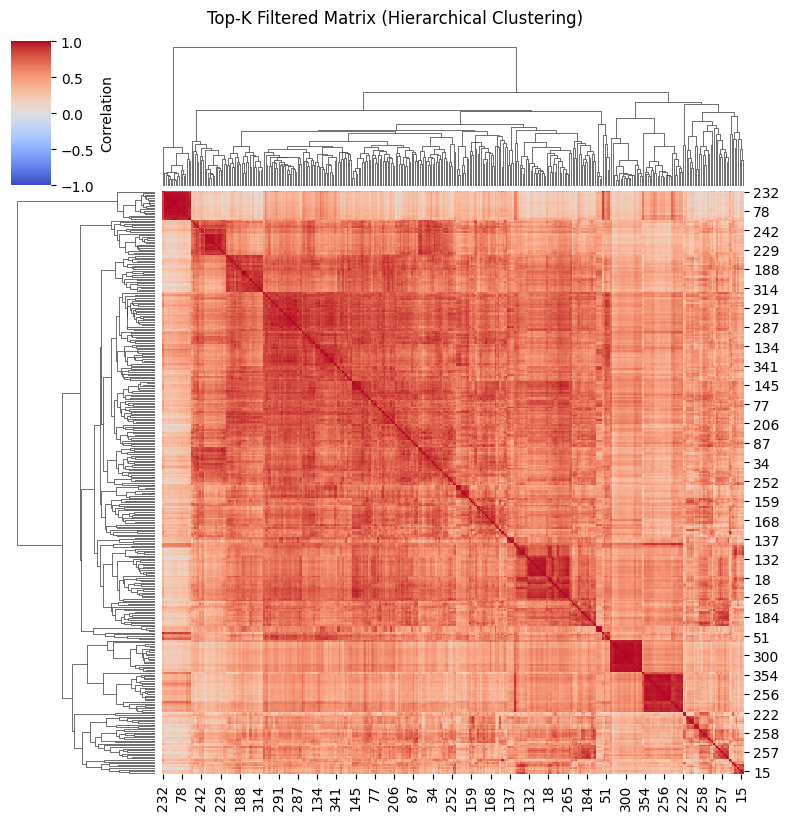

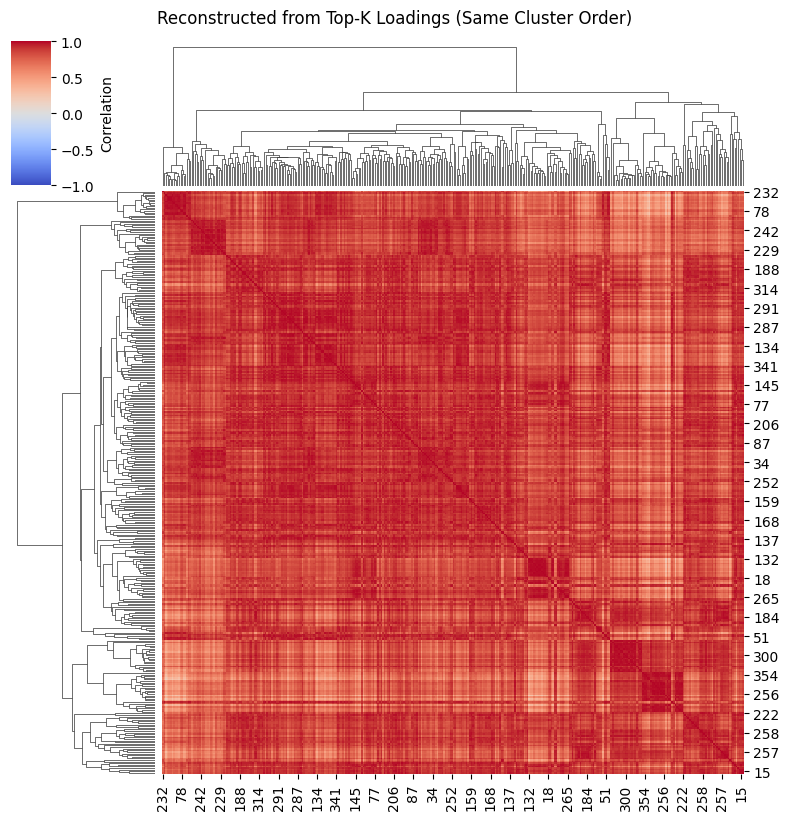

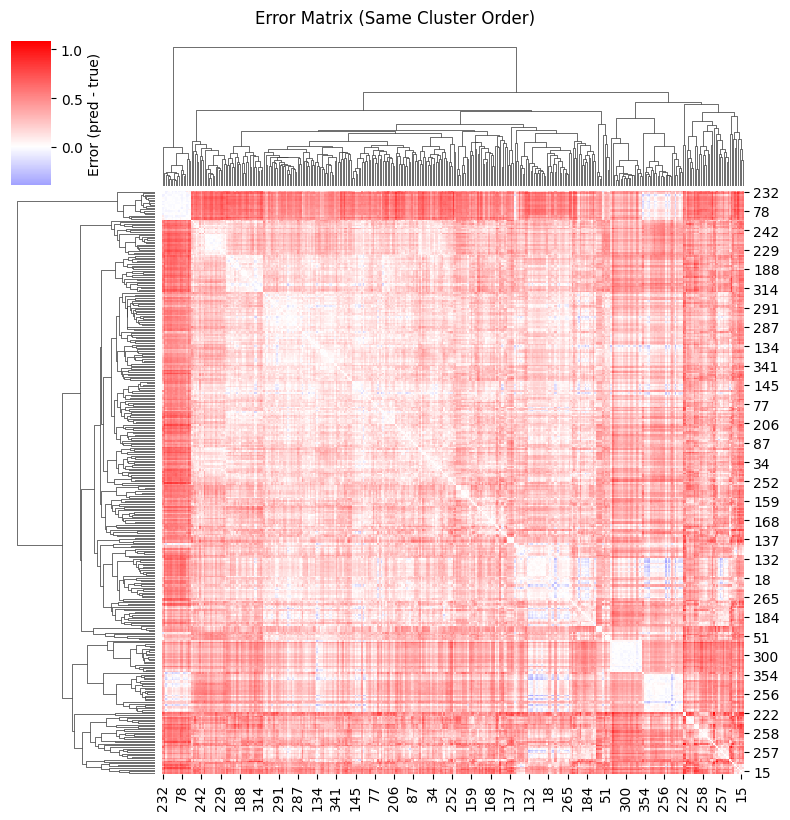

In [126]:
def upper_vec_to_full_corr(vec: torch.Tensor, tri_indices: torch.Tensor, dim: int) -> torch.Tensor:
    """Reconstruct a symmetric correlation matrix from an upper-triangular vector."""
    mat = torch.zeros((dim, dim), dtype=vec.dtype, device=vec.device)
    mat.fill_diagonal_(1.0)
    i, j = tri_indices[0], tri_indices[1]
    mat[i, j] = vec
    mat[j, i] = vec
    return mat


def loadings_vec_to_corr(
    vec: torch.Tensor,
    dim: int,
    num_factors: int,
    eps: float = 1e-8,
):
    """Reconstruct a normalized correlation matrix from flattened weighted loadings."""
    loadings = vec.view(dim, num_factors)
    c_raw = loadings @ loadings.T
    diag_vals = torch.diagonal(c_raw)
    inv_sqrt_diag = torch.rsqrt(torch.clamp(diag_vals, min=eps))
    d_inv_sqrt = torch.diag(inv_sqrt_diag)
    c_corr = d_inv_sqrt @ c_raw @ d_inv_sqrt
    return c_corr, loadings


model.eval()
with torch.no_grad():
    sample_idx = 66
    x_true = X[sample_idx:sample_idx+1].to(DEVICE)  # shape (1, input_dim)
    x_pred, _, _ = model(x_true)                    # shape (1, input_dim)

x_true_vec = x_true.squeeze(0).cpu()
x_pred_vec = x_pred.squeeze(0).cpu()

mse_sample = F.mse_loss(x_pred_vec, x_true_vec).item()
errors = x_pred_vec - x_true_vec
max_err = errors.max().item()
min_err = errors.min().item()
mean_abs_err = errors.abs().mean().item()

print(f"--- Statistics for Sample [{sample_idx}] ---")
print(f"Input mode: {INPUT_MODE}")
print(f"Vector Reconstruction MSE: {mse_sample:.6f}")
print(f"Max Error: {max_err:.6f}")
print(f"Min Error: {min_err:.6f}")
print(f"Mean Absolute Error: {mean_abs_err:.6f}")

if INPUT_MODE == "upper_triangular":
    true_mat = upper_vec_to_full_corr(x_true_vec, tri_u_idx, D)
    pred_mat = upper_vec_to_full_corr(x_pred_vec, tri_u_idx, D)
    title_true = "Original (Hierarchical Clustering)"
    title_pred = "Reconstructed (Same Cluster Order)"
else:
    true_mat, loadings_true = loadings_vec_to_corr(x_true_vec, D, NUM_FACTORS)
    pred_mat, loadings_pred = loadings_vec_to_corr(x_pred_vec, D, NUM_FACTORS)
    mse_loadings = F.mse_loss(loadings_pred, loadings_true).item()
    print(f"Loadings MSE: {mse_loadings:.6f}")
    title_true = "Top-K Filtered Matrix (Hierarchical Clustering)"
    title_pred = "Reconstructed from Top-K Loadings (Same Cluster Order)"

err_mat = pred_mat - true_mat

true_np = true_mat.numpy()
pred_np = pred_mat.numpy()
err_np = err_mat.numpy()

# Build a hierarchical ordering from the reference matrix, then reuse it for comparisons.
g_true = sns.clustermap(
    true_np,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={"label": "Correlation"},
)
g_true.figure.suptitle(title_true, y=1.02)
g_true.figure.savefig(run_dir / f"clustermap_true_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

row_linkage = g_true.dendrogram_row.linkage
col_linkage = g_true.dendrogram_col.linkage

g_pred = sns.clustermap(
    pred_np,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={"label": "Correlation"},
)
g_pred.figure.suptitle(title_pred, y=1.02)
g_pred.figure.savefig(run_dir / f"clustermap_pred_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

g_err = sns.clustermap(
    err_np,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    center=0,
    cmap="bwr",
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={"label": "Error (pred - true)"},
)
g_err.figure.suptitle("Error Matrix (Same Cluster Order)", y=1.02)
g_err.figure.savefig(run_dir / f"clustermap_error_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

In [127]:
model_path = run_dir / f"model_weights_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.pth"
metadata_path = run_dir / f"metadata_w{window_length}_s{stride}_{mode_suffix}_RUN{RUN}.json"

torch.save(model.state_dict(), model_path)

metadata = {
    "run_name": folder_name,
    "input_representation": INPUT_MODE,
    "num_factors": int(NUM_FACTORS) if NUM_FACTORS is not None else None,
    "input_dim": int(input_dim),
    "hidden_dims": HIDDEN_DIMS,
    "latent_dim": LATENT_DIM,
    "batch_size": BATCH_SIZE,
    "beta": float(BETA),
    "optimizer": "Adam",
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "scheduler": "CosineAnnealingWarmRestarts" if USE_SCHEDULER else "None",
    "use_scheduler": bool(USE_SCHEDULER),
    "scheduler_params": {
        "T_0": int(max(1, EPOCHS // 5)),
        "T_mult": 1,
        "eta_min": float(LEARNING_RATE * 1e-2),
    } if USE_SCHEDULER else None,
    "best_val_loss": float(best_val),
    "history": history,
    "selected_file": str(selected_file),
    "matrix_dim": int(D),
    "window_length": int(window_length),
    "stride": int(stride),
    "seed": int(SEED),
    "start_idx": int(start_idx),
    "end_idx": int(end_idx),
    "tickers": list(tickers) if tickers is not None else [],
}

if INPUT_MODE == "upper_triangular":
    metadata["upper_triangular_size"] = int(tri_size)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"Run results saved in: {run_dir}")
print(f"  - Weights: {model_path.name}")
print(f"  - Metadata: {metadata_path.name}")

Run results saved in: /content/drive/MyDrive/best_models_tesi/results_w724_s10_eigK15_RUN8
  - Weights: model_weights_w724_s10_eigK15_RUN8.pth
  - Metadata: metadata_w724_s10_eigK15_RUN8.json
